In [ ]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [ ]:
CONFIG = {
    "lookback": 5,            # Past days used as input sequence
    "hidden_units": 64,       # LSTM units per layer
    "num_layers": 1,          # Stacked LSTM layers
    "dropout": 0.2,           # Dropout rate
    "epochs": 10,            # Max training epochs
    "batch_size": 16,         # Mini-batch size
    "learning_rate": 0.001,   # Initial Adam learning rate
    "test_size": 0.2,         # Fraction for test set (used in train_test_split)
    "forecast_start_date": "1999-11-18",      # Start date for forecasting
    "forecast_days": 10,      # Number of future days to forecast
    "output_dir":   "/mnt/user-data/outputs", # Directory to save model and plots
    "csv_path": "C:\\Python Course\\Projects\\Python\\RNN\\archive\\stocks\\A.csv" # Path to your CSV file
}

In [ ]:
def load_data(csv_path=None):
    df = None
    """Load stock data from a CSV file or fall back to built-in sample data."""
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path, parse_dates=["Date"])
        # check if df has the required columns
        required_columns = {"Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"}
        if not required_columns.issubset(df.columns):
            print(f"  ⚠️ CSV file is missing required columns: {required_columns - set(df.columns)}")
            return None
        print(f"  ✓ Loaded {len(df)} rows from {csv_path}")
        df = df.sort_values("Date").reset_index(drop=True)
    else:
        print("  ⚠️ CSV file not found.")
        
   
    return df

In [ ]:
# Line Chart of Closing Prices Over Time
def Show_Price_Chart(df):
    # Convert 'Date' column to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    plt.figure(figsize=(15, 6))
    plt.plot(df['Date'], df['Close'], marker='.')
    plt.title('Closing Prices Over Time')
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 2. PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

def create_sequences(data, lookback):
    """Convert a 1-D array into (X, Y) sliding-window sequences for LSTM."""
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i, 0])
        Y.append(data[i, 0])
    return np.array(X), np.array(Y)


def preprocess(df, lookback, test_size):
    """
    Scale prices to [0,1], build sequences, and split with train_test_split.
    """
    prices = df["Close"].values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(prices)

    X, Y = create_sequences(scaled, lookback)

    # ── train_test_split (shuffle=False to preserve time order) ───────────
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, shuffle=False
    )

    # Reshape for LSTM: (samples, timesteps, features)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

    split_idx = len(X_train)

    print(f"  ✓ Sequences created  →  Train: {len(X_train)}  |  Test: {len(X_test)}")
    return X_train, X_test, Y_train, Y_test, scaler, split_idx



In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 3. MODEL DEFINITION  (tensorflow.keras)
# ══════════════════════════════════════════════════════════════════════════════

def build_model(lookback, cfg):
    """Build a stacked LSTM model using tensorflow.keras Sequential API."""

    model = Sequential()
    model.add(Input(shape=(lookback, 1)))

       
    model.add(
        LSTM(
            units=cfg["hidden_units"],
            name= "lstm_1",
        )
    )
    model.add(Dropout(cfg["dropout"], name=f"dropout_1"))

    model.add(Dense(32, activation="relu", name="dense_hidden"))
    model.add(Dense(1, name="output"))

    model.compile(
        optimizer=Adam(learning_rate=cfg["learning_rate"]),
        loss="mse",
        metrics=["mae"],
    )
    return model


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 4. TRAINING
# ══════════════════════════════════════════════════════════════════════════════

def train_model(model, X_train, Y_train, X_test, Y_test, cfg):
    """Train with EarlyStopping and ReduceLROnPlateau callbacks."""

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    ]

    print("\n  Training …")
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_test, Y_test),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        callbacks=callbacks,
        verbose=1,
    )

    tl = history.history["loss"]
    vl = history.history["val_loss"]
    total = len(tl)

    print(f"\n  {'Epoch':>7}  {'Train Loss':>12}  {'Val Loss':>12}")
    print("  " + "─" * 35)
    for i in range(0, total, max(1, total // 10)):
        print(f"  {i+1:>7}  {tl[i]:>12.6f}  {vl[i]:>12.6f}")
    print(f"  {total:>7}  {tl[-1]:>12.6f}  {vl[-1]:>12.6f}")
    print("  " + "─" * 35)
    print(f"  ✓ Finished after {total} epochs  (best val_loss: {min(vl):.6f})\n")

    return history



In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 5. EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def evaluate(model, X_train, Y_train, X_test, Y_test, scaler):
    """Generate predictions, inverse-transform, and compute metrics."""

    train_pred = scaler.inverse_transform(model.predict(X_train, verbose=0)).flatten()
    test_pred  = scaler.inverse_transform(model.predict(X_test, verbose=0)).flatten()
    train_actual = scaler.inverse_transform(Y_train.reshape(-1, 1)).flatten()
    test_actual  = scaler.inverse_transform(Y_test.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
    mae  = mean_absolute_error(test_actual, test_pred)
    r2   = r2_score(test_actual, test_pred)
    mape = np.mean(np.abs((test_actual - test_pred) / test_actual)) * 100

    print("  ┌──────────────────────────────────────┐")
    print("  │         TEST SET METRICS              │")
    print("  ├──────────────────────────────────────┤")
    print(f"  │  RMSE  : {rmse:>10.4f}                 │")
    print(f"  │  MAE   : {mae:>10.4f}                 │")
    print(f"  │  R²    : {r2:>10.4f}                 │")
    print(f"  │  MAPE  : {mape:>9.2f}%                 │")
    print("  └──────────────────────────────────────┘")

    return {
        "train_pred": train_pred, "test_pred": test_pred,
        "train_actual": train_actual, "test_actual": test_actual,
        "rmse": rmse, "mae": mae, "r2": r2, "mape": mape,
    }

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 7. VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

def plot_results(df, results, history, forecast_prices, cfg, split_idx, output_dir):
    """Generate a 6-panel dashboard and save as PNG."""

    lookback = cfg["lookback"]
    c = {
        "bg": "#0a0e17", "panel": "#111825", "grid": "#1a2535",
        "actual": "#4a90d9", "train": "#d97050", "test": "#50d990",
        "forecast": "#d9c050", "text": "#c8d0e0", "dim": "#4a6090",
    }

    fig = plt.figure(figsize=(16, 14), facecolor=c["bg"])
    fig.suptitle(
        "LSTM Stock Price Prediction  ·  TensorFlow / Keras",
        fontsize=20, fontweight="bold", color=c["text"], y=0.98,
    )

    dates  = df["Date"].values
    prices = df["Close"].values
    train_dates = dates[lookback : lookback + len(results["train_pred"])]
    test_dates  = dates[lookback + split_idx : lookback + split_idx + len(results["test_pred"])]
    last_date   = pd.Timestamp(dates[-1])
    fcast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=len(forecast_prices))

    def style(ax):
        ax.set_facecolor(c["panel"]); ax.tick_params(colors=c["dim"]); ax.grid(True, alpha=0.15, color=c["grid"])

    # 1 — Main chart
    ax1 = fig.add_subplot(3, 2, (1, 2)); style(ax1)
    ax1.plot(dates, prices, color=c["actual"], lw=1.5, label="Actual", alpha=0.9)
    ax1.plot(train_dates, results["train_pred"], color=c["train"], lw=1.2, ls="--", label="Train Pred", alpha=0.8)
    ax1.plot(test_dates, results["test_pred"], color=c["test"], lw=1.2, ls="--", label="Test Pred", alpha=0.8)
    ax1.plot(fcast_dates, forecast_prices, color=c["forecast"], lw=2, ls=":", marker="o", ms=4, label="Forecast")
    if lookback + split_idx < len(dates):
        ax1.axvline(x=dates[lookback + split_idx], color="#4a3060", ls="--", alpha=0.6, label="Split")
    ax1.set_title("Price Predictions & Forecast", color=c["text"], fontsize=13, pad=10)
    ax1.set_ylabel("Price ($)", color=c["dim"])
    ax1.legend(loc="upper left", fontsize=9, facecolor=c["panel"], edgecolor=c["grid"], labelcolor=c["text"])
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

    # 2 — Loss curves
    ax2 = fig.add_subplot(3, 2, 3); style(ax2)
    ep = range(1, len(history.history["loss"]) + 1)
    ax2.plot(ep, history.history["loss"], color=c["actual"], lw=1.5, label="Train")
    ax2.plot(ep, history.history["val_loss"], color=c["train"], lw=1.5, label="Val")
    ax2.fill_between(ep, history.history["loss"], alpha=0.1, color=c["actual"])
    ax2.fill_between(ep, history.history["val_loss"], alpha=0.1, color=c["train"])
    ax2.set_title("Loss Curve (MSE)", color=c["text"], fontsize=13, pad=10)
    ax2.set_xlabel("Epoch", color=c["dim"]); ax2.set_ylabel("Loss", color=c["dim"])
    ax2.legend(fontsize=9, facecolor=c["panel"], edgecolor=c["grid"], labelcolor=c["text"])

    # 3 — Scatter
    ax3 = fig.add_subplot(3, 2, 4); style(ax3)
    ax3.scatter(results["test_actual"], results["test_pred"], color=c["test"], alpha=0.7, s=40, edgecolors="white", lw=0.3)
    lo = min(results["test_actual"].min(), results["test_pred"].min()) * 0.95
    hi = max(results["test_actual"].max(), results["test_pred"].max()) * 1.05
    ax3.plot([lo, hi], [lo, hi], color=c["train"], ls="--", alpha=0.5, label="Perfect")
    ax3.set_title("Actual vs Predicted (Test)", color=c["text"], fontsize=13, pad=10)
    ax3.set_xlabel("Actual ($)", color=c["dim"]); ax3.set_ylabel("Predicted ($)", color=c["dim"])
    ax3.legend(fontsize=9, facecolor=c["panel"], edgecolor=c["grid"], labelcolor=c["text"])

    # 4 — Error histogram
    ax4 = fig.add_subplot(3, 2, 5); style(ax4)
    errors = results["test_actual"] - results["test_pred"]
    ax4.hist(errors, bins=15, color=c["actual"], alpha=0.7, edgecolor=c["panel"])
    ax4.axvline(0, color=c["forecast"], ls="--", alpha=0.7)
    ax4.axvline(errors.mean(), color=c["train"], alpha=0.7, label=f"Mean: {errors.mean():.3f}")
    ax4.set_title("Error Distribution", color=c["text"], fontsize=13, pad=10)
    ax4.set_xlabel("Error ($)", color=c["dim"]); ax4.set_ylabel("Count", color=c["dim"])
    ax4.legend(fontsize=9, facecolor=c["panel"], edgecolor=c["grid"], labelcolor=c["text"])

    # 5 — Forecast detail
    ax5 = fig.add_subplot(3, 2, 6); style(ax5)
    tail = min(10, len(prices))
    ax5.plot(dates[-tail:], prices[-tail:], color=c["actual"], lw=2, marker="o", ms=4, label="Recent")
    ax5.plot(fcast_dates, forecast_prices, color=c["forecast"], lw=2, marker="s", ms=5, label="Forecast")
    ax5.axvline(x=dates[-1], color="#4a3060", ls="--", alpha=0.6)
    for d, p in zip(fcast_dates, forecast_prices):
        ax5.annotate(f"${p:.2f}", (d, p), textcoords="offset points", xytext=(0, 10), fontsize=7, color=c["forecast"], ha="center")
    ax5.set_title("Forecast Detail", color=c["text"], fontsize=13, pad=10)
    ax5.set_ylabel("Price ($)", color=c["dim"])
    ax5.legend(fontsize=9, facecolor=c["panel"], edgecolor=c["grid"], labelcolor=c["text"])
    ax5.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    path = os.path.join(output_dir, "lstm_stock_prediction.png")
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=c["bg"])
    plt.close()
    print(f"  ✓ Chart saved → {path}")
    return path




  ══════════════════════════════════════════════
   LSTM Stock Market Predictor
   tensorflow.keras  +  sklearn.train_test_split
  ══════════════════════════════════════════════

  ✓ Loaded 5124 rows from C:\Python Course\Projects\Python\RNN\archive\stocks\A.csv
  Date range : 1999-11-18 → 2020-04-01
  Price range: $7.76 – $113.73



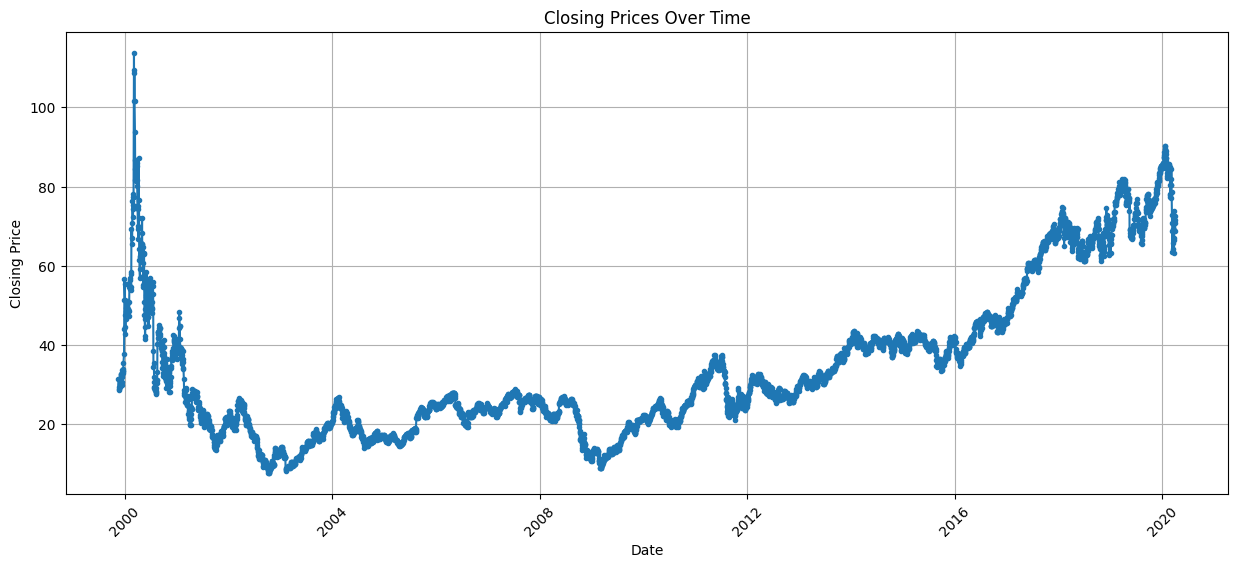

  ✓ Sequences created  →  Train: 4095  |  Test: 1024


  Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 19,009 (74.25 KB)
 Trainable params: 19,009 (74.25 KB)
 Non-trainable params: 0 (0.00 B)


  Training …
Epoch 1/10
2

In [ ]:
# def run ():   

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print()
print("  ══════════════════════════════════════════════")
print("   LSTM Stock Market Predictor")
print("   tensorflow.keras  +  sklearn.train_test_split")
print("  ══════════════════════════════════════════════")
print()

df = load_data(CONFIG["csv_path"])
# if df is None:
    
#     print("  ✗ Failed to load data. Exiting.")
#     return
print(f"  Date range : {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")
print(f"  Price range: ${df['Close'].min():.2f} – ${df['Close'].max():.2f}\n")

Show_Price_Chart(df)

X_train, X_test, Y_train, Y_test, scaler, split_idx = preprocess(
    df, CONFIG["lookback"], CONFIG["test_size"]
)

model = build_model(CONFIG["lookback"], CONFIG)
model.summary(print_fn=lambda s: print(f"  {s}"))

#################################################################################################
history = train_model(model, X_train, Y_train, X_test, Y_test, CONFIG)
    
##################################################################################################
results = evaluate(model, X_train, Y_train, X_test, Y_test, scaler)

scaled_all = scaler.transform(df["Close"].values.reshape(-1, 1)).flatten()
last_seq = scaled_all[-CONFIG["lookback"]:]

    


# run()

In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 6. FORECASTING
# ══════════════════════════════════════════════════════════════════════════════

def forecast_future(model, last_sequence, scaler, start_date, n_days):
    """Autoregressively predict n_days into the future."""
    seq = last_sequence.copy()
    preds = []
    for i in range(n_days):
        x= seq.reshape(1, len(seq), 1)
        current_date = pd.to_datetime(start_date) + pd.Timedelta(days=i)
        print(f"  Predicting for {current_date.date()} → Input seq: {seq.round(4)}", end="")
        print (x.shape)
        pred = model.predict(x, verbose=0)[0, 0]
        preds.append(pred)
        seq = np.append(seq[1:], pred)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()


In [ ]:
import pandas as pd
import numpy as np

def predict_range(model, df, scaler, lookback, from_date, NumberOfdays,
                  feature_col="Close", date_col="Date"         ):
    """
    Recursive multi-step LSTM forecast for a given number of days.

    Returns a DataFrame with columns [Date, Predicted].
    """
    from_date = pd.to_datetime(from_date)
    target_dates = pd.date_range(from_date, periods=NumberOfdays)


    # Seed window: last `lookback` known closes, scaled
    
    series = df[feature_col].values.reshape(-1, 1)
    scaled = scaler.transform(series)                 # use the SAME scaler from training
    window = scaled[-lookback:].copy()                # shape (lookback, 1)

   
    def step(window):
        x = window.reshape(1, lookback, 1)
        yhat_scaled = model.predict(x, verbose=0)[0, 0]
        new_window = np.vstack([window[1:], [[yhat_scaled]]])
        return yhat_scaled, new_window

    # Burn through the gap between last data point and from_date
    for _ in target_dates:
        _, window = step(window)

    # Now produce predictions for the requested range
    preds_scaled = []
    for _ in target_dates:
        yhat, window = step(window)
        print(f"{window}  Predicted for {target_dates[len(preds_scaled)].date()}: {yhat:.4f} (scaled) → {scaler.inverse_transform([[yhat]])[0,0]:.2f} actual)")
        preds_scaled.append(yhat)

    preds = scaler.inverse_transform(
        np.array(preds_scaled).reshape(-1, 1)
    ).ravel()

    return pd.DataFrame({date_col: target_dates, "Predicted": preds})

from_date = "1999-11-18"
NumberOfdays = 10

forecast = predict_range(
    model     = model,
    df        = df,
    scaler    = scaler,            # the one you fit on training data
    lookback  = CONFIG["lookback"],
    from_date = from_date,
    NumberOfdays = NumberOfdays,
)

print(forecast.head())
print(forecast.tail())

[[0.5907709 ]
 [0.59087777]
 [0.59096533]
 [0.59103632]
 [0.59111756]]  Predicted for 1999-11-18: 0.5911 (scaled) → 70.40 actual)
[[0.59087777]
 [0.59096533]
 [0.59103632]
 [0.59111756]
 [0.59119755]]  Predicted for 1999-11-19: 0.5912 (scaled) → 70.41 actual)
[[0.59096533]
 [0.59103632]
 [0.59111756]
 [0.59119755]
 [0.59127551]]  Predicted for 1999-11-20: 0.5913 (scaled) → 70.42 actual)
[[0.59103632]
 [0.59111756]
 [0.59119755]
 [0.59127551]
 [0.59135294]]  Predicted for 1999-11-21: 0.5914 (scaled) → 70.43 actual)
[[0.59111756]
 [0.59119755]
 [0.59127551]
 [0.59135294]
 [0.59143013]]  Predicted for 1999-11-22: 0.5914 (scaled) → 70.44 actual)
[[0.59119755]
 [0.59127551]
 [0.59135294]
 [0.59143013]
 [0.5915066 ]]  Predicted for 1999-11-23: 0.5915 (scaled) → 70.44 actual)
[[0.59127551]
 [0.59135294]
 [0.59143013]
 [0.5915066 ]
 [0.59158236]]  Predicted for 1999-11-24: 0.5916 (scaled) → 70.45 actual)
[[0.59135294]
 [0.59143013]
 [0.5915066 ]
 [0.59158236]
 [0.59165758]]  Predicted for 1999

In [ ]:
import pandas as pd
import numpy as np

def predict_on_date(model, df, scaler, lookback, target_date,
                    feature_col="Close", date_col="Date"):
    """
    Predict (or backtest) the value on a single date.

    - If target_date is in df  -> uses the lookback window ending just before it
                                  (true one-step prediction, comparable to actual).
    - If target_date is after df -> falls back to recursive forecasting.
    """
    target_date = pd.to_datetime(target_date)
    df = df.sort_values(date_col).reset_index(drop=True)
    last_known = pd.to_datetime(df[date_col].iloc[-1])

    series_scaled = scaler.transform(df[feature_col].values.reshape(-1, 1))

    # --- Case A: target is inside df (backtest) ---
    if target_date <= last_known:
        idx = df.index[df[date_col] == target_date]
        if len(idx) == 0:
           print(f"  ⚠️ {target_date.date()} not found in df.")
           return
        i = idx[0]
        if i < lookback:
           print(f"  ⚠️ Not enough history before {target_date.date()} (need {lookback} prior rows, have {i}).")
           return
        window = series_scaled[i - lookback : i]          # real values, no recursion
        x = window.reshape(1, lookback, 1)
        yhat_scaled = model.predict(x, verbose=0)[0, 0]
        yhat   = scaler.inverse_transform([[yhat_scaled]])[0, 0]
        actual = df[feature_col].iloc[i]
        print(f"  Predicted for {target_date.date()}: {yhat:.2f}  |  Actual: {actual:.2f}  |  Error: {yhat - actual:.2f} (backtest)")
      

    # --- Case B: target is in the future (recursive forecast) ---
    window = series_scaled[-lookback:].copy()
    steps = pd.date_range(last_known + pd.Timedelta(days=1), target_date, freq="B")
    yhat_scaled = None
    for _ in steps:
        x = window.reshape(1, lookback, 1)
        yhat_scaled = model.predict(x, verbose=0)[0, 0]
        window = np.vstack([window[1:], [[yhat_scaled]]])
    yhat = scaler.inverse_transform([[yhat_scaled]])[0, 0]
    print(f"  Predicted for {target_date.date()}: {yhat:.2f} (forecast, {len(steps)} steps ahead)")
        
    
predict_on_date(model, df, scaler, CONFIG["lookback"], "1999-11-26")  # backtest
predict_on_date(model, df, scaler, CONFIG["lookback"], "2020-06-15")  # forecast

  Predicted for 1999-11-26: 29.44  |  Actual: 29.46  |  Error: -0.02 (backtest)
  Predicted for 1999-11-26: nan (forecast, 0 steps ahead)
  Predicted for 2020-06-15: 70.70 (forecast, 53 steps ahead)
